In [1]:
!pip install deap --quiet

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 29.9 MB/s eta 0:00:00


## 1. CARGA DE INSUMOS DEL MÓDULO 1

In [2]:
SALIDAS = "salidas"
ruta_json = f"{SALIDAS}/resultados_m1.json"

if not os.path.exists(ruta_json):
    raise FileNotFoundError(f"No se encontró {ruta_json}. Ejecuta el Módulo 1 primero.")

with open(ruta_json, "r", encoding="utf-8") as f:
    datos_m1 = json.load(f)

TICKERS = datos_m1["tickers"]
N = len(TICKERS)
RF = 0.0

# Cargar los datos de rendimientos del mercado (asumiendo que guardaste mu y Sigma o los recalculamos rápidamente)
# Para mantener la independencia del bloque, descargamos de nuevo o cargamos los numpy arrays si los guardaste.
# Como el JSON no guarda matrices completas, reconstruyamos mu y Sigma rápido para el GA:
import yfinance as yf
print(f"Sincronizando datos para los {N} activos mineros...")
precios = yf.download(TICKERS, start="2015-01-01", end="2024-12-31", progress=False)['Close']
precios = precios.dropna(how="all").ffill().bfill()
retornos = np.log(precios / precios.shift(1)).dropna()
mu = retornos.mean().values * 252
Sigma = retornos.cov().values * 252

Sincronizando datos para los 5 activos mineros...


/tmp/ipykernel_7542/1296504869.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precios = yf.download(TICKERS, start="2015-01-01", end="2024-12-31", progress=False)['Close']


## 2. CONFIGURACIÓN DE DEAP PARA NSGA-II

In [3]:
# Objetivo: Minimizar Riesgo (peso -1.0) y Maximizar Retorno (peso 1.0)
if "FitnessMulti" in creator.__dict__:
    del creator.FitnessMulti
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# Generador de genes: números reales entre 0 y 1
toolbox.register("attr_float", random.uniform, 0, 1)

# Generador de individuos: lista de N genes
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=N)

# Generador de población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Función de Evaluación (Fitness)
def evaluar_portafolio(individual):
    pesos = np.array(individual)
    suma = np.sum(pesos)

    # Penalización severa si todos los pesos son cero
    if suma == 0:
        return 1e9, -1e9

    # Normalizamos para que la suma sea 1 estricta
    pesos = pesos / suma

    # Cálculos matriciales de portafolio
    retorno_esperado = np.dot(pesos, mu)
    riesgo_volatilidad = np.sqrt(np.dot(pesos, np.dot(Sigma, pesos)))

    return riesgo_volatilidad, retorno_esperado

toolbox.register("evaluate", evaluar_portafolio)

# Operadores Genéticos continuos
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=0.0, up=1.0, eta=20.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=0.0, up=1.0, eta=20.0, indpb=1.0/N)
toolbox.register("select", tools.selNSGA2)

## 3. EJECUCIÓN DEL ALGORITMO GENÉTICO

In [4]:
def ejecutar_nsga2(pop_size=200, n_gen=100, cxpb=0.9, mutpb=0.1):
    random.seed(42)
    np.random.seed(42)

    pop = toolbox.population(n=pop_size)

    # Estadísticas para seguimiento
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    print(f"Iniciando NSGA-II: {pop_size} individuos, {n_gen} generaciones...")

    # Algoritmo evolutivo mu+lambda base para NSGA-II
    pop, logbook = algorithms.eaMuPlusLambda(
        pop, toolbox, mu=pop_size, lambda_=pop_size,
        cxpb=cxpb, mutpb=mutpb, ngen=n_gen,
        stats=stats, verbose=False
    )

    # Extraer el frente de Pareto final
    frente_pareto = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]
    return frente_pareto, logbook

frente_pareto, logbook = ejecutar_nsga2(pop_size=300, n_gen=150)

Iniciando NSGA-II: 300 individuos, 150 generaciones...


## 4. PROCESAMIENTO DE RESULTADOS

In [5]:
riesgos_ga = []
retornos_ga = []
pesos_ga = []

for ind in frente_pareto:
    p_norm = np.array(ind) / np.sum(ind)
    r, e = evaluar_portafolio(ind)
    riesgos_ga.append(r)
    retornos_ga.append(e)
    pesos_ga.append(p_norm.tolist())

# Buscar el portafolio con el mejor Sharpe Ratio dentro del GA
sharpes_ga = (np.array(retornos_ga) - RF) / np.array(riesgos_ga)
idx_max_sharpe_ga = np.argmax(sharpes_ga)

## 5. VISUALIZACIÓN Y COMPARACIÓN (GA vs Analítico)

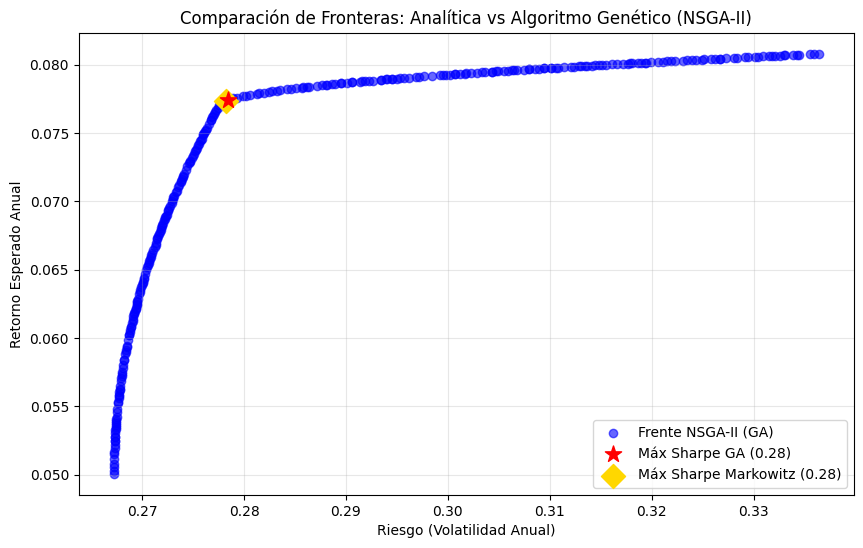

In [6]:
plt.figure(figsize=(10, 6))

# Dibujar el frente del GA
plt.scatter(riesgos_ga, retornos_ga, c="blue", alpha=0.6, label="Frente NSGA-II (GA)", marker="o")

# Resaltar el Máximo Sharpe del GA
plt.scatter(riesgos_ga[idx_max_sharpe_ga], retornos_ga[idx_max_sharpe_ga],
            c="red", s=150, marker="*", zorder=5,
            label=f"Máx Sharpe GA ({sharpes_ga[idx_max_sharpe_ga]:.2f})")

# Si guardaste la frontera analítica en el Módulo 1 (requiere extraerla o recalcularla):
# Usaremos los puntos del Markowitz Max Sharpe y Min Varianza del json como referencia
mk_s_riesgo = datos_m1["markowitz_max_sharpe"]["riesgo"]
mk_s_retorno = datos_m1["markowitz_max_sharpe"]["retorno"]
mk_s_sharpe = datos_m1["markowitz_max_sharpe"]["sharpe"]

plt.scatter(mk_s_riesgo, mk_s_retorno, c="gold", s=150, marker="D", zorder=4,
            label=f"Máx Sharpe Markowitz ({mk_s_sharpe:.2f})")

plt.title("Comparación de Fronteras: Analítica vs Algoritmo Genético (NSGA-II)")
plt.xlabel("Riesgo (Volatilidad Anual)")
plt.ylabel("Retorno Esperado Anual")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{SALIDAS}/fig_frente_nsga2.png", dpi=130)
plt.show()

## 6. EXPORTACIÓN DE RESULTADOS M2

In [7]:
resultados_m2 = {
    "nsga2_max_sharpe": {
        "retorno": float(retornos_ga[idx_max_sharpe_ga]),
        "riesgo": float(riesgos_ga[idx_max_sharpe_ga]),
        "sharpe": float(sharpes_ga[idx_max_sharpe_ga]),
        "pesos": dict(zip(TICKERS, np.round(pesos_ga[idx_max_sharpe_ga], 4).tolist()))
    }
}

with open(f"{SALIDAS}/resultados_m2.json", "w", encoding="utf-8") as f:
    json.dump(resultados_m2, f, ensure_ascii=False, indent=2)

print(f"\nArchivo del Módulo 2 guardado exitosamente: {SALIDAS}/resultados_m2.json")


Archivo del Módulo 2 guardado exitosamente: salidas/resultados_m2.json
